In [ ]:
import torch
import torch.nn as nn

# test Transformer model
# input: sequence of 64 vector, each vector has 1500 features
# output: classification for each vector in the sequqnce (8 classes)

# Transformer Classifier
class TransformerClassifier(nn.Module):
    def __init__(self, input_features, hidden_dim=256, nhead=8, num_layers=2, output_dim=8):
        super(TransformerClassifier, self).__init__()
        self.input_embedding = nn.Linear(input_features, hidden_dim)
        
        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, 
                                                    dim_feedforward=hidden_dim*4, 
                                                    batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, input_features]
        x = self.input_embedding(x)  # [batch_size, seq_len, hidden_dim]
        print(f"Input embedding: {x.size()}")
        
        # Pass through transformer
        x = self.transformer_encoder(x)  # [batch_size, seq_len, hidden_dim]
        print(f"Transformer output: {x.size()}")
        
        # Project to output classes
        x = self.output_layer(x)  # [batch_size, seq_len, output_dim]
        print(f"Output layer: {x.size()}")
        
        return x

# Create model with sequence length parameter
model = TransformerClassifier(input_features=1500, hidden_dim= 256, output_dim=8)

# sample input
# INPUT: batch_size , seq_len , features
# batch_size = 10, seq_len = 50, features = 1500
# OUTPUT: batch_size x seq_len x output_dim
y = torch.randn(10, 50, 1500)
print(f"Input: {y.size()}")
output = model(y)
print(f"Output: {output.size()}")




In [ ]:
import torch
import torch.nn as nn

# Byte-level Transformer
# Transformer model for analysing packets at byte level
# The model is used to analyse packets with 1500 bytes (Maximum transmission unit)
# Each byte is represent as a 8-bit vector
# Each 8-bit vector is then expand to 64 features using embedding layer
# Transformer model is used to analyse the sequence of 1500 vectors
# Output is a vector at custom dimension represent the packet
# INPUT: sequence of 1500 vector, each vector has 8 features
# OUTPUT: vector with custom dimension represent the packet

class ByteLevelTransformer(nn.Module):
    def __init__(self, output_dim, hidden_dim=64, nhead=8, num_layers=2):
        super(ByteLevelTransformer, self).__init__()
        # Input is 8-bit binary vectors
        self.input_projection = nn.Linear(8, hidden_dim)
        
        # Positional encoding for 1500 bytes
        self.pos_encoder = nn.Parameter(torch.zeros(1, 1500, hidden_dim))
        nn.init.normal_(self.pos_encoder, mean=0, std=0.1)
        
        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, 
                                                    dim_feedforward=hidden_dim*4, 
                                                    batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # Global average pooling for sequence aggregation
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Output projection to custom dimension
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: [batch_size, 1500, 8] - each byte as 8-bit vector
        x = self.input_projection(x)  # [batch_size, 1500, hidden_dim]
        
        # Add positional encoding
        x = x + self.pos_encoder
        
        # Pass through transformer
        x = self.transformer_encoder(x)  # [batch_size, 1500, hidden_dim]
        
        # Global pooling across sequence dimension
        x = x.transpose(1, 2)  # [batch_size, hidden_dim, 1500]
        x = self.pool(x).squeeze(-1)  # [batch_size, hidden_dim]
        
        # Project to output dimension
        output = self.output_layer(x)  # [batch_size, output_dim]
        
        return output

# Create model with output dimension 128
model = ByteLevelTransformer(output_dim=128)

# sample input
# INPUT: batch_size , seq_len
# batch_size = 10, seq_len = 1500
# OUTPUT: batch_size x output_dim
y = torch.randint(0, 256, (10, 1500)).float()
print(f"Input: {y.size()}")
output = model(y)
print(f"Output: {output.size()}")

In [ ]:
import torch
import torch.nn as nn
import math
from torch import Tensor

class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x: Tensor) -> Tensor:
        """
        Arguments:
            x: Tensor, shape ``[batch_size, seq_len, embedding_dim]``
        """
        x = x + self.pe[:,:x.size(1)]
        return self.dropout(x) 

# Flattening Approach for ByteLevelTransformer
class ByteLevelTransformer(nn.Module):
    def __init__(self, output_dim, hidden_dim=16, nhead=2, num_layers=1):
        super(ByteLevelTransformer, self).__init__()
        
        self.embedding_byte = nn.Embedding(256,hidden_dim)

        self.pos_encoder = PositionalEncoding(hidden_dim)
        
        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, 
                                                   dim_feedforward=hidden_dim*4, 
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # Flattening and MLP layers
        flattened_dim = 1500 * hidden_dim
        self.mlp = nn.Sequential(
            nn.Linear(flattened_dim, 1500),
            nn.ReLU(),
            nn.Linear(1500, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim)
        )
        
    def forward(self, x):
        # x shape: [batch_size, 1500] - sequence of 1500 byte as a vector
        # print(f"Input: {x.size()}")
        x = self.embedding_byte(x)  # [batch_size, 1500, hidden_dim]
        # print(f"Embedding: {x.size()}")

        # Add positional encoding
        x = self.pos_encoder(x)
        # print(f"Positional Encoding: {x.size()}")
        
        # Pass through transformer
        x = self.transformer_encoder(x)  # [batch_size, 1500, hidden_dim]
        # print(f"Transformer output: {x.size()}")
        
        # Flatten the output
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)  # [batch_size, 1500*hidden_dim]
        # print(f"Flattened: {x.size()}")
        
        # Pass through MLP layers
        output = self.mlp(x)  # [batch_size, output_dim]
        # print(f"Output: {output.size()}")
        
        return output
    
# Create model with output dimension 256
# model = ByteLevelTransformer(output_dim=256)

# # sample input
# # INPUT: batch_size , seq_len
# # batch_size = 10, seq_len = 1500
# # OUTPUT: batch_size x output_dim
# x = torch.randint(0, 256, (10, 1500)).float()
# print(f"Input: {x.size()}")
# output = model(x)
# print(f"Output: {output.size()}")

class PacketLevelTransformer(nn.Module):
    '''
    Transformer model for classify packets.
    Input: sequence of packets (each packet has 1500 bytes)
    Output: classification for each packet in the sequence
    '''
    def __init__(self, input_features, hidden_dim=256, nhead=4, num_layers=1, output_dim=8):
        super(PacketLevelTransformer, self).__init__()

        self.bytelevel_transformer = ByteLevelTransformer(output_dim=hidden_dim)
        
        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, 
                                                   dim_feedforward=hidden_dim*4, 
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, 1500] - sequence of packets of 1500 bytes
        x = x.long()  # Convert to long for embedding

        # Pass through byte-level transformer
        x = torch.stack([self.bytelevel_transformer(seq) for seq in x])  # [batch_size, seq_len, hidden_dim]
        print(f"Byte-level Transformer output: {x.size()}")

        # Pass through transformer
        x = self.transformer_encoder(x)  # [batch_size, seq_len, hidden_dim]
        print(f"Transformer output: {x.size()}")
        
        # Project to output classes
        output = self.output_layer(x)  # [batch_size, seq_len, output_dim]
        
        return output
    
# Create model with output dimension 8
model = PacketLevelTransformer(input_features=1500, hidden_dim=256, output_dim=8)
print(sum(p.numel() for p in model.parameters()))

# sample input
# INPUT: batch_size , seq_len
# batch_size = 10, seq_len = 1500
# OUTPUT: batch_size x output_dim
y = torch.randint(0, 256, (10, 64, 1500))
print(f"Input: {y.size()}")
output = model(y)
print(f"Output: {output.size()}")

37700532
Input: torch.Size([10, 64, 1500])
Byte-level Transformer output: torch.Size([10, 64, 256])
Transformer output: torch.Size([10, 64, 256])
Output: torch.Size([10, 64, 8])


In [ ]:
from IDS_lib import *
import math 
model = TransformerClassifier(input_features=PACKET_LEN)  # Using default parameters
print(model)
print(sum(p.numel() for p in model.parameters()))
print(sum(p.numel() for p in model.parameters() if p.requires_grad))
# sample input
# INPUT: batch_size , seq_len, features
# batch_size = 10, seq_len = 64, features = 1500
# OUTPUT: batch_size x output_dim
y = torch.randint(0, 256, (10, 64, 1500))
print(f"Input: {y.size()}")
output = model(y.float())
print(f"Output: {output.size()}")

model2 = TwoLevelTransformer(input_features=PACKET_LEN, output_dim=NUM_CLASS)  # Using default parameters
print(model2)
print(sum(p.numel() for p in model2.parameters()))
print(sum(p.numel() for p in model2.parameters() if p.requires_grad))
# sample input
# INPUT: batch_size , seq_len, features
# batch_size = 10, seq_len = 64, features = 1500
# OUTPUT: batch_size x output_dim
y = torch.randint(0, 256, (10, 64, 1500))
print(f"Input: {y.size()}")
output = model2(y)
print(f"Output: {output.size()}")

Device: cuda
TransformerClassifier(
  (input_embedding): Sequential(
    (0): Linear(in_features=1500, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=256, out_features=8,

In [ ]:
import torch

def bytes_to_bits(byte_tensor):
    """
    Convert a tensor of byte values (0-255) to 8-bit binary representation.
    
    Args:
        byte_tensor: Tensor of shape [batch_size, seq_len] with values 0-255
    
    Returns:
        Tensor of shape [batch_size, seq_len, 8] with binary values (0 or 1)
    """
    # Create bit positions tensor (7, 6, 5, ..., 0) for MSB to LSB
    bit_positions = torch.arange(7, -1, -1, device=byte_tensor.device)
    
    # Extract bits using right shift and masking
    # Reshape for broadcasting
    byte_expanded = byte_tensor.unsqueeze(-1)  # [batch_size, seq_len, 1]
    bit_positions = bit_positions.reshape(1, 1, 8)  # [1, 1, 8]
    
    # Extract each bit
    bits = ((byte_expanded >> bit_positions) & 1).float()
    
    return bits

# Example usage
batch_size = 10
seq_len = 1500
y = torch.randint(0, 256, (batch_size, seq_len))
print(f"Input shape: {y.shape}")

# Convert to bit representation
x_bits = bytes_to_bits(y)
print(f"Output shape: {x_bits.shape}")

# Example: Show the binary representation of the first byte in the first sequence
example_byte = y[0, 0].item()
example_bits = x_bits[0, 0].int().tolist()
print(f"Decimal {example_byte} = Binary {example_bits}")

In [ ]:
import torch
import torch.nn as nn

encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8)
src = torch.rand(10, 32, 512)
out = encoder_layer(src)
print(out.shape)

# Test Expanding input

In [ ]:
import torch
import torch.nn as nn

class MultiLayerMLP(nn.Module):
    '''
    Transformer model for classify packets.
    Input: sequence of packets (each packet has 1500 bytes)
    Output: classification for each packet in the sequence
    '''
    def __init__(self, input_features=1500, byte_emb_dim=8, packet_emb_dim=256, output_dim=8):
        super(MultiLayerMLP, self).__init__()

        # Byte-level MLP
        # Embedding layer for byte-level input
        self.embedding_byte = nn.Embedding(256,byte_emb_dim)
        # MLP for byte-level features
        self.l1 = nn.Linear(byte_emb_dim, byte_emb_dim*2)
        # Linear compression layer for each byte
        self.l_compress = nn.Linear(byte_emb_dim*2, 1)

        # Output projection of the packet to custom dimension
        self.l_projection_layer = nn.Linear(input_features, packet_emb_dim)

        # Packet-level MLP
        self.l2 = nn.Linear(packet_emb_dim, packet_emb_dim*2)
        self.l3 = nn.Linear(packet_emb_dim*2, packet_emb_dim)
        
        # Output layer
        self.output_layer = nn.Linear(packet_emb_dim, output_dim)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, features = 1500] - sequence of packets of 1500 bytes
        # print(f"Input shape: {x.shape}")
        
        # Convert x to [batch_size x seq_len, 1500]
        batch_size, seq_len, feature_dim = x.size()
        x = x.reshape(-1, feature_dim ) # [batch_size x seq_len, 1500]
        # print(f"After reshape: {x.shape}")

        x = self.embedding_byte(x.int())  # [batch_size x seq_len, 1500, byte_emb_dim]
        # print(f"After embedding: {x.shape}")

        # Pass through byte-level MLP
        x = torch.relu(self.l1(x)) # [batch_size x seq_len, 1500, byte_emb_dim*2]
        # print(f"After MLP: {x.shape}")
        
        # Linear compression
        x = torch.relu(self.l_compress(x)) # [batch_size x seq_len, 1500, 1]
        # print(f"After linear compression: {x.shape}")
        
        x = x.squeeze(-1)   # [batch_size x seq_len, 1500]
        # print(f"After squeeze: {x.shape}")

        # Reshape back to [batch_size, seq_len, 1500]
        x = x.reshape(batch_size, seq_len, -1)
        # print(f"After reshaping back: {x.shape}")

        # Project to output dimension
        x = torch.relu(self.l_projection_layer(x))  # [batch_size, seq_len, packet_emb_dim]
        # print(f"After projection: {x.shape}")

        # Pass through packet-level MLP
        x = torch.relu(self.l2(x))  # [batch_size, seq_len, packet_emb_dim*2]
        # print(f"After packet-level 2 MLP: {x.shape}")
        x = torch.relu(self.l3(x)) # [batch_size, seq_len, packet_emb_dim]
        # print(f"After packet-level 3 MLP: {x.shape}")
        
        # Project to output classes
        output = self.output_layer(x)  # [batch_size, seq_len, output_dim]
        # print(f"Output shape: {output.shape}")
        
        return output
    
model = MultiLayerMLP(input_features=1500, byte_emb_dim=8, packet_emb_dim=256, output_dim=8)
print(model)


# sample input
# INPUT: batch_size , seq_len, features
# batch_size = 10, seq_len = 64, features = 1500
# OUTPUT: batch_size x output_dim
y = torch.randint(0, 256, (10, 64, 1500))
print(f"Input: {y.size()}")
output = model(y)
print(f"Output: {output.size()}")

MultiLayerMLP(
  (embedding_byte): Embedding(256, 8)
  (l1): Linear(in_features=8, out_features=16, bias=True)
  (l_compress): Linear(in_features=16, out_features=1, bias=True)
  (l_projection_layer): Linear(in_features=1500, out_features=256, bias=True)
  (l2): Linear(in_features=256, out_features=512, bias=True)
  (l3): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=8, bias=True)
)
Input: torch.Size([10, 64, 1500])
Output: torch.Size([10, 64, 8])


# test transformer encoder layer

In [6]:
encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True)
src = torch.rand(32, 10, 512)
out = encoder_layer(src)
print(out.shape)

torch.Size([32, 10, 512])


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

a = torch.randn(5, 64, 1500)
b = torch.randn(6, 64, 1500)
c = torch.concat([a, b], dim=0)
print(c.size())
d = torch.mean(c, dim=0)
print(d.size()) 

torch.Size([11, 64, 1500])
torch.Size([64, 1500])


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

# Create a simple dataset
class SimpleDataset(Dataset):
    def __init__(self, num_samples=100, seq_len=3, packet_len=5):
        self.data = torch.randint(0, 256, (num_samples, seq_len, packet_len))
        self.labels = torch.randint(0, 8, (num_samples, seq_len))  # 8 classes
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Create dataset and dataloader
dataset = SimpleDataset()
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batch size: {dataloader.batch_size}")
print(f"Number of batches: {len(dataloader)}")

# Iterate through the dataloader
for i in range(len(dataloader)):
    inputs, labels = next(iter(dataloader))
    print(f"Batch {i}:")
    print(f"  Input shape: {inputs.shape}")
    print(f"  Labels shape: {labels.shape}")
    print(f"  Input data: ", inputs)
    
    # Break after a few iterations for demonstration
    if i >= 2:
        break

Dataset size: 100
Batch size: 4
Number of batches: 25
Batch 0:
  Input shape: torch.Size([4, 3, 5])
  Labels shape: torch.Size([4, 3])
  Input data:  tensor([[[  0, 243, 140, 216,  28],
         [167, 163,  49, 127,  39],
         [178, 196, 106,  18,   3]],

        [[132, 195, 185, 133, 240],
         [165, 206, 131, 242, 149],
         [129,  39, 151, 115, 225]],

        [[200, 254, 148, 178, 186],
         [ 19,  49, 112, 197,  59],
         [205, 112,  20,  88, 156]],

        [[141, 136, 146, 167,  35],
         [ 29,  31, 154, 139, 134],
         [ 61, 205,  96,  74, 236]]])
Batch 1:
  Input shape: torch.Size([4, 3, 5])
  Labels shape: torch.Size([4, 3])
  Input data:  tensor([[[107,  34,  11, 243, 124],
         [255,  49,  29, 143, 249],
         [154, 221,  51, 125, 162]],

        [[102, 109, 195, 206,  85],
         [116, 146, 158, 236,  63],
         [ 59, 113,   0, 190, 119]],

        [[157,  68, 185,  94, 148],
         [ 65, 125, 149,  71, 214],
         [ 88, 194,  8

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

folder_path = './datasets/'

# Get feature name
featurenamefile = folder_path+'Feature_name.dat'
with open(featurenamefile) as file:
    feature_name = [line.rstrip() for line in file]
file.close()
ft_dict = {key: i for i, key in enumerate(feature_name)}
n_feature = len(feature_name)

df_eval_normal = pd.read_csv(folder_path+'normal/normal_eval_NAS_Traffic_21_Apr_2024_05_01.csv',header=None, names=feature_name)

print(df_eval_normal.shape)

n_samples = int(df_eval_normal.shape[0]*0.01) # 1% of the data

# choose a random number between 0 and df_eval_normal.shape[0]
random_index = np.random.randint(0, df_eval_normal.shape[0])

# get n_samples rows from df_eval_normal starting from random_index
df_eval_normal_sample = df_eval_normal[random_index:random_index+n_samples].copy()
print(df_eval_normal_sample.shape)
df_eval_normal_sample['label'] = 0

# drop sampled rows from df_eval_normal
df_eval_normal.drop(df_eval_normal.index[random_index:random_index+n_samples], inplace=True)
print(df_eval_normal.shape)

# save df_eval_normal to a csv file
df_eval_normal.to_csv('normal_eval_NAS_Traffic_21_Apr_2024_05_01_95percent.csv', index=False, header=None)


# Drop columns
drop_columns = ['idx','level','session_id','ue_id','direction']
df_eval_normal_sample.drop(columns=drop_columns, inplace=True)
df_eval_normal_sample['packet_hex'] = df_eval_normal_sample['packet_hex'].map(lambda x: x[2:])

# zero-ing time stamp
def zerotime(df):
    min_timestamp = df['timestamp'].min()
    df['timestamp']= df['timestamp'].apply(lambda x: x-min_timestamp)

zerotime(df_eval_normal_sample)

# save df_eval_normal_sample to a csv file
df_eval_normal_sample.to_csv('normal_eval_NAS_Traffic_21_Apr_2024_05_01_sample_1percent_preprocessed.csv', index=False)

(140778, 7)
(1407, 7)
(139371, 7)


In [ ]:
import torch
import torch.nn.functional as F
# create a random float tensor
# INPUT: 2,3,4
# OUTPUT: 2,3,4
y = torch.randn(2, 3, 4)
print(f"Input: {y.size()}")
print(y)
# apply softmax to the last dimension
y = F.softmax(y, dim=-1)
print(f"Output: {y.size()}")
# print the output
print(y)

# apply softmax to the last dimension again
y = F.softmax(y, dim=-1)
print(f"Output: {y.size()}")
# print the output
print(y)


Input: torch.Size([2, 3, 4])
tensor([[[ 0.0240, -0.2618, -1.5750,  0.8908],
         [-0.6781, -0.1581, -1.0478,  0.6234],
         [ 1.0798,  0.1441, -0.2337, -0.4814]],

        [[-0.4060, -0.0606,  0.5724,  2.5419],
         [-0.3764,  0.0161, -0.6947, -0.7452],
         [-1.1658, -1.3106,  1.0252, -0.7995]]])
Output: torch.Size([2, 3, 4])
tensor([[[0.2308, 0.1734, 0.0466, 0.5491],
         [0.1419, 0.2387, 0.0980, 0.5214],
         [0.5345, 0.2097, 0.1437, 0.1122]],

        [[0.0414, 0.0585, 0.1102, 0.7898],
         [0.2564, 0.3797, 0.1865, 0.1773],
         [0.0816, 0.0706, 0.7300, 0.1177]]])
Output: torch.Size([2, 3, 4])
tensor([[[0.2409, 0.2275, 0.2004, 0.3312],
         [0.2212, 0.2437, 0.2117, 0.3233],
         [0.3274, 0.2366, 0.2215, 0.2146]],

        [[0.1922, 0.1955, 0.2059, 0.4063],
         [0.2508, 0.2837, 0.2338, 0.2317],
         [0.2025, 0.2003, 0.3873, 0.2099]]])


In [18]:
import torch
import torch.nn.functional as F

# create a random float tensor of size 2,3,4
x = torch.randn(2, 3, 4)
y = torch.randn(2, 3, 4)
print(f"Input: {y.size()}")
# print the input
print(y)
# apply softmax to the last dimension
y = F.softmax(y, dim=-1)
print(f"Softmax: {y.size()}")
# print the output
print(y)
# convert to index
y = torch.argmax(y, dim=-1)
print(f"Argmax: {y.size()}")
# print the output
print(y)

# compute the cross entropy loss
index_loss = F.cross_entropy(x.view(-1,4), y.view(-1))
print(f"Index loss: {index_loss.item()}")

# convert to one hot
y = F.one_hot(y, num_classes=4)
print(f"onehot: {y.size()}")
# print the output
print(y)

# compute the cross entropy loss
onehot_loss = F.cross_entropy(x.view(-1,4), y.view(-1,4).float())
print(f"One hot loss: {onehot_loss.item()}")

Input: torch.Size([2, 3, 4])
tensor([[[ 0.9970,  1.1885,  1.5847, -1.4799],
         [ 0.8292,  0.5431,  0.6097,  0.0707],
         [ 0.1049,  0.1287, -0.1629,  1.2454]],

        [[-0.8661,  0.9125,  0.3470, -1.4795],
         [ 0.8097,  1.5681,  0.5544,  0.3798],
         [ 1.2014, -0.4279,  0.0252, -2.3524]]])
Softmax: torch.Size([2, 3, 4])
tensor([[[0.2442, 0.2957, 0.4395, 0.0205],
         [0.3308, 0.2485, 0.2656, 0.1550],
         [0.1690, 0.1731, 0.1293, 0.5287]],

        [[0.0924, 0.5469, 0.3107, 0.0500],
         [0.2193, 0.4682, 0.1699, 0.1427],
         [0.6522, 0.1279, 0.2012, 0.0187]]])
Argmax: torch.Size([2, 3])
tensor([[2, 0, 3],
        [1, 1, 0]])
Index loss: 1.9910311698913574
onehot: torch.Size([2, 3, 4])
tensor([[[0, 0, 1, 0],
         [1, 0, 0, 0],
         [0, 0, 0, 1]],

        [[0, 1, 0, 0],
         [0, 1, 0, 0],
         [1, 0, 0, 0]]])
One hot loss: 1.9910311698913574


In [ ]:
import numpy as np
from collections import defaultdict

def dirichlet_skew_split(x, y, num_clients=3, alpha=0.5):
    from numpy.random import dirichlet
    clients_data = defaultdict(list)
    num_classes = len(np.unique(y))
    class_indices = [np.where(y == i)[0] for i in range(num_classes)]

    for c in range(num_classes):
        np.random.shuffle(class_indices[c])
        proportions = dirichlet([alpha] * num_clients)
        proportions = (np.cumsum(proportions) * len(class_indices[c])).astype(int)[:-1]
        splits = np.split(class_indices[c], proportions)
        for client_id, split in enumerate(splits):
            clients_data[client_id].extend(split)
    
    return clients_data


# Example usage
x = np.random.rand(50, 10)
print('shape of x:', x.shape)
# print(x)
y = np.random.randint(0, 4, size=50)  # 4 classes
# print(y)
print('shape of y:', y.shape)
clients_data = dirichlet_skew_split(x, y, num_clients=3, alpha=0.5)
for client_id, indices in clients_data.items():
    print(f"Client {client_id}: {len(indices)} samples")
    print(f"Indices: {indices}")


shape of x: (50, 10)
shape of y: (50,)


In [2]:
import pandas as pd

TRAIN_PRIVATE_DATA_PATH = './datasets/federated_datasets_noslowite_nosqlmap/train/private'
TRAIN_PUBLIC_DATA_PATH = './datasets/federated_datasets_noslowite_nosqlmap/train/public'
EVAL_DATA_PATH  = './datasets/federated_datasets_noslowite_nosqlmap/eval/'

# load csv files from TRAIN_PRIVATE_DATA_PATH and show stat
def load_and_show_stats(path):
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    for file in files:
        df = pd.read_csv(os.path.join(path, file))
        print(f"File: {file}")
        print(f"Shape: {df.shape}")
        print(f"Columns: {df.columns.tolist()}")
        print(f"Sample data:\n{df.head()}\n")
        # Show class distribution
        if 'label' in df.columns:
            class_counts = df['label'].value_counts()
            print(f"Class distribution:\n{class_counts}\n")
        else:
            print("No 'label' column found for class distribution.\n")

import os
load_and_show_stats(TRAIN_PRIVATE_DATA_PATH)
load_and_show_stats(TRAIN_PUBLIC_DATA_PATH)
load_and_show_stats(EVAL_DATA_PATH)


File: private_region_dataset_5.csv
Shape: (91899, 3)
Columns: ['timestamp', 'packet_hex', 'label']
Sample data:
   timestamp                                         packet_hex  label
0          0  45000034ee3040003f06c906c0a80116c0a80226075bbe...      0
1          0  45000038ee3140003f06c901c0a80116c0a80226075bbe...      0
2          0  45000034507440003f0666c3c0a80116c0a80226075b89...      0
3          0  450000341b0140003f069c36c0a80116c0a80226075be1...      0
4          0  450000afb6bd40004006fefec0a80226c0a8011689bd07...      0

Class distribution:
label
5    64452
0    27447
Name: count, dtype: int64

File: private_region_dataset_2.csv
Shape: (37444, 3)
Columns: ['timestamp', 'packet_hex', 'label']
Sample data:
   timestamp                                         packet_hex  label
0          0  45000028000040004006b643c0a80226c0a80116e91707...      0
1          0  45000028000040004006b643c0a80226c0a80116e91707...      0
2         70  4500003cd0f440004006e542c0a8021ec0a80116805107.

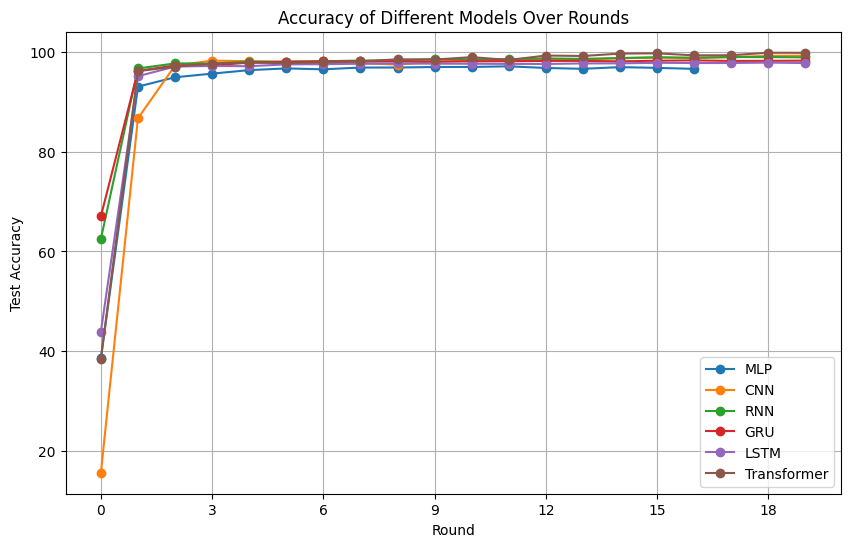

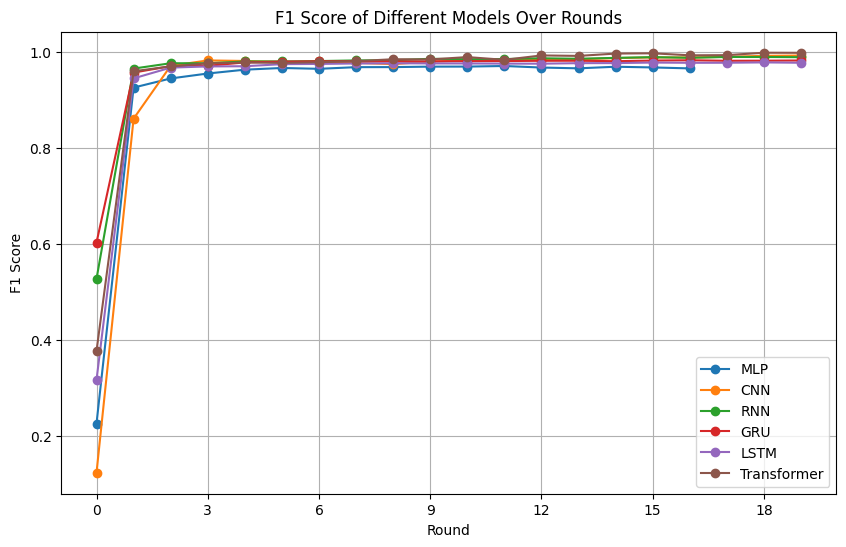

Last Round Metrics:
MLP: F1 score: 0.965571, Accuracy: 96.584209
CNN: F1 score: 0.992379, Accuracy: 99.239521
RNN: F1 score: 0.988915, Accuracy: 98.900488
GRU: F1 score: 0.982027, Accuracy: 98.236492
LSTM: F1 score: 0.977257, Accuracy: 97.756754
Transformer: F1 score: 0.998014, Accuracy: 99.802342


In [ ]:
import pickle
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay,accuracy_score,f1_score
from matplotlib.ticker import MaxNLocator

# Load the round metrics from the pickle file
RESULTS_FOLDER_PATH = './result3006/FL/'
# MLP model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FL_MLP.pkl', 'rb') as f:
    round_metrics_MLP = pickle.load(f)
# CNN model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FL_CNN.pkl', 'rb') as f:
    round_metrics_CNN = pickle.load(f)
# RNN model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FL_RNN.pkl', 'rb') as f:
    round_metrics_RNN = pickle.load(f)
# GRU model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FL_GRU.pkl', 'rb') as f:
    round_metrics_GRU = pickle.load(f)
# LSTM model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FL_LSTM.pkl', 'rb') as f:
    round_metrics_LSTM = pickle.load(f) 
# Transformer model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FL_Transformer.pkl', 'rb') as f:
    round_metrics_Transformer = pickle.load(f)

global_accuracy_MLP = round_metrics_MLP['global_accuracy']
global_accuracy_CNN = round_metrics_CNN['global_accuracy']
global_accuracy_RNN = round_metrics_RNN['global_accuracy']
global_accuracy_GRU = round_metrics_GRU['global_accuracy']
global_accuracy_LSTM = round_metrics_LSTM['global_accuracy']
global_accuracy_Transformer = round_metrics_Transformer['global_accuracy']

# Plot global accuracy for each model
plt.figure(figsize=(10, 6))
plt.plot(global_accuracy_MLP, label='MLP', marker='o')
plt.plot(global_accuracy_CNN, label='CNN', marker='o')
plt.plot(global_accuracy_RNN, label='RNN', marker='o')
plt.plot(global_accuracy_GRU, label='GRU', marker='o')
plt.plot(global_accuracy_LSTM, label='LSTM', marker='o')
plt.plot(global_accuracy_Transformer, label='Transformer', marker='o')
plt.title('Accuracy of Different Models Over Rounds')
plt.xlabel('Round')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid()
plt.savefig(RESULTS_FOLDER_PATH + 'test_accuracy_over_rounds.png')
plt.show()

# Plot F1 score for each model
plt.figure(figsize=(10, 6))
plt.plot(round_metrics_MLP['global_f1_weighted'], label='MLP', marker='o')
plt.plot(round_metrics_CNN['global_f1_weighted'], label='CNN', marker='o')
plt.plot(round_metrics_RNN['global_f1_weighted'], label='RNN', marker='o')
plt.plot(round_metrics_GRU['global_f1_weighted'], label='GRU', marker='o')
plt.plot(round_metrics_LSTM['global_f1_weighted'], label='LSTM', marker='o')
plt.plot(round_metrics_Transformer['global_f1_weighted'], label='Transformer', marker='o')
plt.title('F1 Score of Different Models Over Rounds')
plt.xlabel('Round')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel('F1 Score')
plt.legend()
plt.grid()
plt.savefig(RESULTS_FOLDER_PATH + 'f1_score_over_rounds.png')
plt.show()

# print last round metrics for each model with 6 decimal places
print("Last Round Metrics:")
print(f"MLP: F1 score: {round_metrics_MLP['global_f1_weighted'][-1]:.6f}, Accuracy: {round_metrics_MLP['global_accuracy'][-1]:.6f}")
print(f"CNN: F1 score: {round_metrics_CNN['global_f1_weighted'][-1]:.6f}, Accuracy: {round_metrics_CNN['global_accuracy'][-1]:.6f}")
print(f"RNN: F1 score: {round_metrics_RNN['global_f1_weighted'][-1]:.6f}, Accuracy: {round_metrics_RNN['global_accuracy'][-1]:.6f}")
print(f"GRU: F1 score: {round_metrics_GRU['global_f1_weighted'][-1]:.6f}, Accuracy: {round_metrics_GRU['global_accuracy'][-1]:.6f}")
print(f"LSTM: F1 score: {round_metrics_LSTM['global_f1_weighted'][-1]:.6f}, Accuracy: {round_metrics_LSTM['global_accuracy'][-1]:.6f}")
print(f"Transformer: F1 score: {round_metrics_Transformer['global_f1_weighted'][-1]:.6f}, Accuracy: {round_metrics_Transformer['global_accuracy'][-1]:.6f}")

In [23]:
from IDS_lib import *
import os

# create sample model for MLP, CNN, RNN, GRU, LSTM, Transformer
mlp_model = MLPClassifier(input_features=PACKET_LEN, hidden_dim=256, output_dim=NUM_CLASS)
cnn_model = CNNClassifier(input_features=PACKET_LEN, output_dim=NUM_CLASS)
rnn_model = RNNClassifier(input_features=PACKET_LEN, hidden_dim=256, output_dim=NUM_CLASS)
gru_model = GRUClassifier(input_features=PACKET_LEN, hidden_dim=256, output_dim=NUM_CLASS)
lstm_model = LSTMClassifier(input_features=PACKET_LEN, hidden_dim=256, output_dim=NUM_CLASS)
model = TransformerClassifier(input_features=PACKET_LEN, hidden_dim=256, output_dim=NUM_CLASS)

# save each model to a file and check file size
torch.save(mlp_model.state_dict(), 'sample_mlp_classifier.pth')
file_size = os.path.getsize('sample_mlp_classifier.pth')
print(f"MLP model file size: {file_size / (1024):.2f} KB") 

torch.save(cnn_model.state_dict(), 'sample_cnn_classifier.pth')
file_size = os.path.getsize('sample_cnn_classifier.pth')
print(f"CNN model file size: {file_size / (1024):.2f} KB") 

torch.save(rnn_model.state_dict(), 'sample_rnn_classifier.pth')
file_size = os.path.getsize('sample_rnn_classifier.pth')
print(f"RNN model file size: {file_size / (1024):.2f} KB") 

torch.save(gru_model.state_dict(), 'sample_gru_classifier.pth')
file_size = os.path.getsize('sample_gru_classifier.pth')
print(f"GRU model file size: {file_size / (1024):.2f} KB") 

torch.save(lstm_model.state_dict(), 'sample_lstm_classifier.pth')
file_size = os.path.getsize('sample_lstm_classifier.pth')
print(f"LSTM model file size: {file_size / (1024):.2f} KB") 


torch.save(model.state_dict(), 'sample_transformer_classifier.pth')
file_size = os.path.getsize('sample_transformer_classifier.pth')
print(f"Transformer model file size: {file_size / (1024):.2f} KB")

# Sum all model file sizes
total_model_size = sum([
    os.path.getsize('sample_mlp_classifier.pth'),
    os.path.getsize('sample_cnn_classifier.pth'),
    os.path.getsize('sample_rnn_classifier.pth'),
    os.path.getsize('sample_gru_classifier.pth'),
    os.path.getsize('sample_lstm_classifier.pth'),
    os.path.getsize('sample_transformer_classifier.pth')
])

# Convert to MB for better readability
total_model_size_mb = total_model_size / (1024 * 1024)
print(f"Total model file sizes: {total_model_size_mb:.2f} MB")

# Calculate average model size
avg_model_size = total_model_size / 6
print(f"Average model file size: {avg_model_size / 1024:.2f} KB")

# create a sample output tensor
# size: 60929 x 6 
output_tensor = torch.randn(60929, NUM_CLASS)
# save the output tensor to a file
torch.save(output_tensor, 'sample_output_tensor.pth')
# get file size of the saved output tensor in KB
output_file_size = os.path.getsize('sample_output_tensor.pth')
print(f"Output tensor file size: {output_file_size / (1024):.2f} KB")

# ratio of output tensor file size to transformer model file size
output_to_transformer_ratio = output_file_size / os.path.getsize('sample_transformer_classifier.pth')
print(f"Output tensor to Transformer model file size ratio: {output_to_transformer_ratio:.2f}")

MLP model file size: 3649.73 KB
CNN model file size: 10944.18 KB
RNN model file size: 3781.23 KB
GRU model file size: 5321.23 KB
LSTM model file size: 6091.30 KB
Transformer model file size: 9702.73 KB
Total model file sizes: 38.56 MB
Average model file size: 6581.73 KB
Output tensor file size: 1429.22 KB
Output tensor to Transformer model file size ratio: 0.15


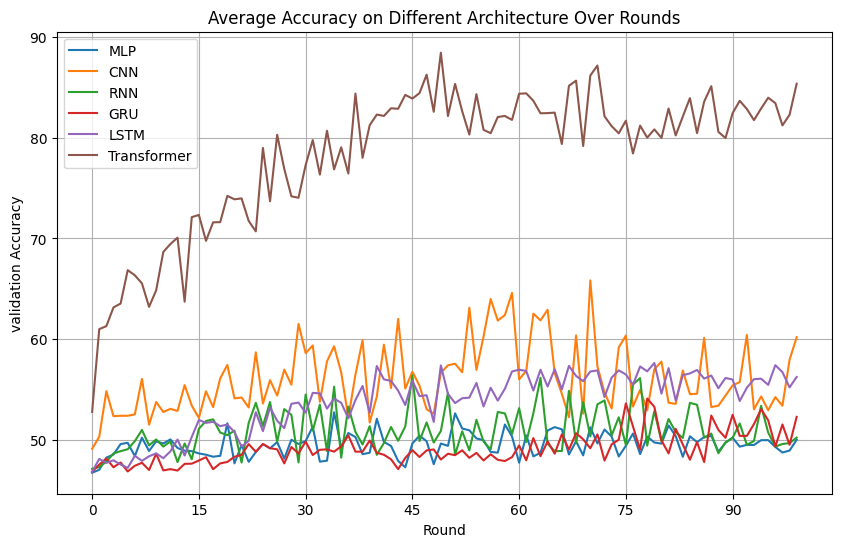

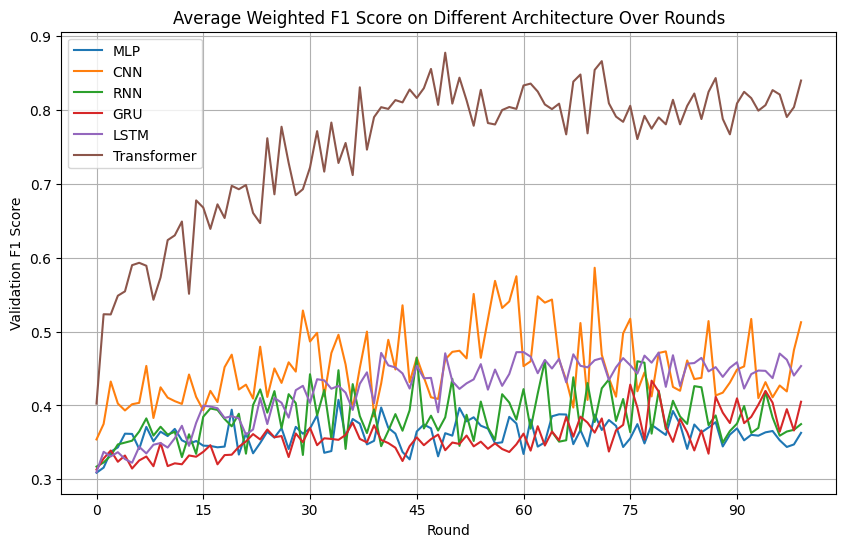

Last Round Metrics:
Model 1:
MLP: F1 score: 0.2699, Accuracy: 42.16
CNN: F1 score: 0.7176, Accuracy: 74.09
RNN: F1 score: 0.2562, Accuracy: 41.26
GRU: F1 score: 0.3147, Accuracy: 44.44
LSTM: F1 score: 0.2581, Accuracy: 41.33
Transformer: F1 score: 0.7719, Accuracy: 79.52
Model 2:
MLP: F1 score: 0.2490, Accuracy: 39.51
CNN: F1 score: 0.3503, Accuracy: 45.51
RNN: F1 score: 0.2559, Accuracy: 39.82
GRU: F1 score: 0.2402, Accuracy: 38.17
LSTM: F1 score: 0.1924, Accuracy: 35.66
Transformer: F1 score: 0.9109, Accuracy: 91.03
Model 3:
MLP: F1 score: 0.4364, Accuracy: 55.17
CNN: F1 score: 0.5155, Accuracy: 60.00
RNN: F1 score: 0.5102, Accuracy: 59.27
GRU: F1 score: 0.3609, Accuracy: 50.22
LSTM: F1 score: 0.3580, Accuracy: 50.07
Transformer: F1 score: 0.8653, Accuracy: 86.75
Model 4:
MLP: F1 score: 0.4661, Accuracy: 60.63
CNN: F1 score: 0.5799, Accuracy: 68.49
RNN: F1 score: 0.5238, Accuracy: 62.83
GRU: F1 score: 0.4667, Accuracy: 59.63
LSTM: F1 score: 0.7679, Accuracy: 80.38
Transformer: F1 sco

In [32]:
import pickle
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay,accuracy_score,f1_score
from matplotlib.ticker import MaxNLocator

# Load the round metrics from the pickle file
RESULTS_FOLDER_PATH = './'

# MLP model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FD_MLP.pkl', 'rb') as f:
    round_metrics_MLP = pickle.load(f)
# CNN model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FD_CNN.pkl', 'rb') as f:
    round_metrics_CNN = pickle.load(f)
# RNN model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FD_RNN.pkl', 'rb') as f:
    round_metrics_RNN = pickle.load(f)
# GRU model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FD_GRU.pkl', 'rb') as f:
    round_metrics_GRU = pickle.load(f)
# LSTM model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FD_LSTM.pkl', 'rb') as f:
    round_metrics_LSTM = pickle.load(f)
# Transformer model
with open(RESULTS_FOLDER_PATH + 'round_metrics_FD_Transformer.pkl', 'rb') as f:
    round_metrics_Transformer = pickle.load(f)

global_accuracy_MLP = round_metrics_MLP['avg_models_accuracy']
global_accuracy_CNN = round_metrics_CNN['avg_models_accuracy']
global_accuracy_RNN = round_metrics_RNN['avg_models_accuracy']
global_accuracy_GRU = round_metrics_GRU['avg_models_accuracy']
global_accuracy_LSTM = round_metrics_LSTM['avg_models_accuracy']
global_accuracy_Transformer = round_metrics_Transformer['avg_models_accuracy']

# Plot global accuracy for each model
plt.figure(figsize=(10, 6))
plt.plot(global_accuracy_MLP, label='MLP')
plt.plot(global_accuracy_CNN, label='CNN')
plt.plot(global_accuracy_RNN, label='RNN')
plt.plot(global_accuracy_GRU, label='GRU')
plt.plot(global_accuracy_LSTM, label='LSTM')
plt.plot(global_accuracy_Transformer, label='Transformer')
plt.title('Average Accuracy on Different Architecture Over Rounds')
plt.xlabel('Round')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel('validation Accuracy')
plt.legend()
plt.grid()
plt.savefig(RESULTS_FOLDER_PATH + 'validation_accuracy_over_rounds_FD.png')
plt.show()


# F1 score for each model
avg_f1_score_MLP = round_metrics_MLP['avg_models_f1_weighted']
avg_f1_score_CNN = round_metrics_CNN['avg_models_f1_weighted']
avg_f1_score_RNN = round_metrics_RNN['avg_models_f1_weighted']
avg_f1_score_GRU = round_metrics_GRU['avg_models_f1_weighted']
avg_f1_score_LSTM = round_metrics_LSTM['avg_models_f1_weighted']
avg_f1_score_Transformer = round_metrics_Transformer['avg_models_f1_weighted']

# Plot F1 score for each model
plt.figure(figsize=(10, 6))
plt.plot(avg_f1_score_MLP, label='MLP')
plt.plot(avg_f1_score_CNN, label='CNN')
plt.plot(avg_f1_score_RNN, label='RNN')
plt.plot(avg_f1_score_GRU, label='GRU')
plt.plot(avg_f1_score_LSTM, label='LSTM')
plt.plot(avg_f1_score_Transformer, label='Transformer')
plt.title('Average Weighted F1 Score on Different Architecture Over Rounds')
plt.xlabel('Round')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel('Validation F1 Score')
plt.legend()
plt.grid()
plt.savefig(RESULTS_FOLDER_PATH + 'f1_score_over_rounds_FD.png')
plt.show()

# print last round metrics for each model with 6 decimal places
print("Last Round Metrics:")
for model_idx in range(5):
    print(f"Model {model_idx + 1}:")
    print(f"MLP: F1 score: {round_metrics_MLP['global_f1_weighted'][model_idx][-1]:.4f}, Accuracy: {round_metrics_MLP['global_accuracy'][model_idx][-1]:.2f}")
    print(f"CNN: F1 score: {round_metrics_CNN['global_f1_weighted'][model_idx][-1]:.4f}, Accuracy: {round_metrics_CNN['global_accuracy'][model_idx][-1]:.2f}")
    print(f"RNN: F1 score: {round_metrics_RNN['global_f1_weighted'][model_idx][-1]:.4f}, Accuracy: {round_metrics_RNN['global_accuracy'][model_idx][-1]:.2f}")
    print(f"GRU: F1 score: {round_metrics_GRU['global_f1_weighted'][model_idx][-1]:.4f}, Accuracy: {round_metrics_GRU['global_accuracy'][model_idx][-1]:.2f}")
    print(f"LSTM: F1 score: {round_metrics_LSTM['global_f1_weighted'][model_idx][-1]:.4f}, Accuracy: {round_metrics_LSTM['global_accuracy'][model_idx][-1]:.2f}")
    print(f"Transformer: F1 score: {round_metrics_Transformer['global_f1_weighted'][model_idx][-1]:.4f}, Accuracy: {round_metrics_Transformer['global_accuracy'][model_idx][-1]:.2f}")    

In [43]:
print(len(round_metrics_Transformer['global_accuracy'][3]))

100


In [41]:
# open the pickle file private_test_results_FD_Transformer.pkl
with open(RESULTS_FOLDER_PATH + 'private_test_results_FD_Transformer.pkl', 'rb') as f:
    private_test_results_Transformer = pickle.load(f)

print(private_test_results_Transformer[3]['accuracy'])

38.68224557522124


In [1]:
import torch
# sample integer tensor of size 2,3,4
sample_tensor = torch.randint(0, 10, (2, 3, 4))
print(f"Sample tensor shape: {sample_tensor}")
# sample integer tensor of size 2,3
sample_tensor_2 = torch.randint(0, 10, (2, 3))
print(f"Sample tensor 2 shape: {sample_tensor_2}")

# element-wise multiplication of sample_tensor and sample_tensor_2
result_tensor = sample_tensor * sample_tensor_2.unsqueeze(-1)  # Broadcasting sample_tensor_2 to match the last dimension of sample_tensor
print(f"Result tensor shape: {result_tensor.shape}")
# print the result tensor
print(result_tensor)

Sample tensor shape: tensor([[[6, 5, 6, 9],
         [6, 2, 7, 3],
         [1, 6, 5, 5]],

        [[8, 5, 1, 2],
         [6, 7, 5, 3],
         [1, 5, 9, 9]]])
Sample tensor 2 shape: tensor([[1, 9, 9],
        [0, 7, 3]])
Result tensor shape: torch.Size([2, 3, 4])
tensor([[[ 6,  5,  6,  9],
         [54, 18, 63, 27],
         [ 9, 54, 45, 45]],

        [[ 0,  0,  0,  0],
         [42, 49, 35, 21],
         [ 3, 15, 27, 27]]])


In [13]:
from IDS_lib import *
from torchinfo import summary

hidden_dim = 256
# Initialize different model architectures
mlp_model = MLPClassifier(input_features=PACKET_LEN, output_dim=NUM_CLASS, hidden_dim=hidden_dim)
cnn_model = CNNClassifier(input_features=PACKET_LEN, output_dim=NUM_CLASS)
rnn_model = RNNClassifier(input_features=PACKET_LEN, hidden_dim=hidden_dim, output_dim=NUM_CLASS)
gru_model = GRUClassifier(input_features=PACKET_LEN, hidden_dim=hidden_dim, output_dim=NUM_CLASS)
lstm_model = LSTMClassifier(input_features=PACKET_LEN, hidden_dim=hidden_dim, output_dim=NUM_CLASS)
transformer_model = TransformerClassifier(input_features=PACKET_LEN, hidden_dim=hidden_dim, output_dim=NUM_CLASS)

models = [("MLP", mlp_model), ("CNN", cnn_model), ("RNN", rnn_model), 
            ("GRU", gru_model), ("LSTM", lstm_model), ("Transformer", transformer_model)]

# Print model properties
# for name, model in models:
#     print(f"{name} Model:")
#     print(summary(model, input_size=(BATCH_SIZE, SEQ_LEN, PACKET_LEN), col_names=["input_size", "output_size", "num_params", "trainable"],depth=1))


# create a sample input tensor
BATCH_SIZE = 16
SEQ_LEN = 256
PACKET_LEN = 1500
sample_input = torch.randint(0, 256, (BATCH_SIZE, SEQ_LEN, PACKET_LEN)).float() # Random input tensor

# input and model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_input = sample_input.to(device)  # Move to device if using GPU
for name, model in models:
    model.to(device)

# Measure the time taken for each model's forward pass
import time
for name, model in models:
    print(f"\n{name} Model Forward Pass:")
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation for inference
        start_time = time.time()
        output = model(sample_input)
        end_time = time.time()
    print(f"{name} Model Forward Pass Time: {(end_time - start_time) * 1000:.2f} milliseconds")
    print(f"Output shape: {output.shape}\n")


MLP Model Forward Pass:
MLP Model Forward Pass Time: 0.92 milliseconds
Output shape: torch.Size([16, 256, 6])


CNN Model Forward Pass:
CNN Model Forward Pass Time: 0.69 milliseconds
Output shape: torch.Size([16, 256, 6])


RNN Model Forward Pass:
RNN Model Forward Pass Time: 0.53 milliseconds
Output shape: torch.Size([16, 256, 6])


GRU Model Forward Pass:
GRU Model Forward Pass Time: 2.77 milliseconds
Output shape: torch.Size([16, 256, 6])


LSTM Model Forward Pass:
LSTM Model Forward Pass Time: 2.74 milliseconds
Output shape: torch.Size([16, 256, 6])


Transformer Model Forward Pass:
Transformer Model Forward Pass Time: 0.96 milliseconds
Output shape: torch.Size([16, 256, 6])



In [8]:
# read csv file
file_path = "./datasets/federated_datasets_noslowite_nosqlmap/train/public/public_shared_dataset.csv"

df = pd.read_csv(file_path)
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Make sample tensor of size (60929, 6)
sample_tensor = torch.randn(60929, 6)
# Save the tensor to a file
torch.save(sample_tensor, 'sample_tensor.pth')
# measure the file size
file_size = os.path.getsize('sample_tensor.pth') * 0.8
print(f"Sample tensor file size: {file_size / (1024*1024):.2f} MB")

DataFrame shape: (60929, 3)
Columns: ['timestamp', 'packet_hex', 'label']
Sample tensor file size: 1.12 MB


In [ ]:
# test create directory
import os
# Create a new directory and move all results files there
results_dir = './testfolder'

# Check if the directory exists, if not, create it
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
else:
    # If the directory exists, add number to the directory name
    i = 1
    while os.path.exists(f"{results_dir}_{i}"):
        i += 1
    results_dir = f"{results_dir}_{i}"
    os.makedirs(results_dir)
